In [5]:
import os, sys
import polars as pl

project_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')) 
sys.path.append(project_path)

sys.path.append(project_path)

from src.utils.experiments_exploration_utils import process_experiment_3_results, plot_experiment_3_results
from config.config_experiment_2 import (
    PROP_ERRORS_THRESHOLD,
    N_REALIZATIONS,
    CONFIG_EXPERIMENT
)

DATA_IDS = list(CONFIG_EXPERIMENT.keys())
MODES = ['3a', '3b']

In [6]:
df_results, df_avg_results = {x: {} for x in DATA_IDS}, {x: {} for x in DATA_IDS}

for data_id in DATA_IDS:

    print('-'*50)
    print(data_id.upper())
    print('-'*50)

    for mode in MODES:

        print('-'*50)
        print(f'experiment_{mode}')
        print('-'*50)

        try:

            results_dir = os.path.join(project_path, 'results', f'experiment_{mode}', data_id)
            filename = f'results_exp_{mode}_{data_id}.pkl'
            results_path = os.path.join(results_dir, filename)

            df, df_avg = process_experiment_3_results(
                results_path=results_path,
                prop_errors_threshold=PROP_ERRORS_THRESHOLD
            )
            
            df_results[data_id][mode] = df.clone()
            df_avg_results[data_id][mode] = df_avg.clone()
            
            with pl.Config(tbl_rows=-1):
                display(df_avg)

        except Exception as e:
            print(e)

--------------------------------------------------
SIMULATION_BASE
--------------------------------------------------
--------------------------------------------------
experiment_3a
--------------------------------------------------
✅ Archivo cargado correctamente. Tipo de objeto: <class 'dict'>
📊 Número de realizaciones (seeds) capturadas: 100


n_splits,sample_size_pct,mean_acc,std_acc,mean_ari,std_ari,mean_time,std_time,prop_status_error
i64,f64,f64,f64,f64,f64,f64,f64,f64
3,20.0,0.8558,0.106104,0.667734,0.196027,2.576259,1.614143,0.0
3,30.0,0.850285,0.113762,0.664107,0.200751,2.451331,1.429436,0.0
3,40.0,0.854819,0.110139,0.668732,0.196051,2.544624,1.412471,0.0
5,20.0,0.854105,0.107569,0.664283,0.194942,2.536099,1.627335,0.0
5,30.0,0.852857,0.106398,0.661963,0.196096,2.396991,1.496897,0.0
5,40.0,0.858054,0.100723,0.668698,0.190376,2.313638,1.386006,0.0
10,20.0,0.845187,0.108686,0.644252,0.201506,2.612374,1.669192,0.0
10,30.0,0.849071,0.106515,0.651709,0.198382,2.419093,1.580105,0.0
10,40.0,0.853086,0.103132,0.657901,0.196551,2.228133,1.399581,0.0


--------------------------------------------------
experiment_3b
--------------------------------------------------
✅ Archivo cargado correctamente. Tipo de objeto: <class 'dict'>
📊 Número de realizaciones (seeds) capturadas: 100


n_splits,sample_size_pct,mean_acc,std_acc,mean_ari,std_ari,mean_time,std_time,prop_status_error
i64,f64,f64,f64,f64,f64,f64,f64,f64
3,20.0,0.889775,0.015109,0.708323,0.030288,2.574607,1.628329,0.0
3,30.0,0.887796,0.011809,0.703528,0.026052,2.45666,1.440239,0.0
3,40.0,0.886704,0.012429,0.701213,0.027225,2.576263,1.449153,0.0
5,20.0,0.885882,0.018375,0.699586,0.038889,2.549176,1.622184,0.0
5,30.0,0.88951,0.011161,0.70707,0.024258,2.410344,1.4582,0.0
5,40.0,0.88776,0.010169,0.70314,0.022391,2.307665,1.321641,0.0
10,20.0,0.887534,0.008722,0.7017,0.019652,2.632829,1.714466,0.0
10,30.0,0.888102,0.00804,0.703164,0.01802,2.416737,1.542045,0.0
10,40.0,0.888591,0.008183,0.704414,0.018319,2.222625,1.409054,0.0


--------------------------------------------------
SIMULATION_SIZE_1
--------------------------------------------------
--------------------------------------------------
experiment_3a
--------------------------------------------------
❌ Error: El archivo no existe. Revisa el DATA_ID o la ruta.
cannot access local variable 'results' where it is not associated with a value
--------------------------------------------------
experiment_3b
--------------------------------------------------
❌ Error: El archivo no existe. Revisa el DATA_ID o la ruta.
cannot access local variable 'results' where it is not associated with a value
--------------------------------------------------
SIMULATION_DIM_1
--------------------------------------------------
--------------------------------------------------
experiment_3a
--------------------------------------------------
❌ Error: El archivo no existe. Revisa el DATA_ID o la ruta.
cannot access local variable 'results' where it is not associated with a va

--------------------------------------------------
SIMULATION_BASE
--------------------------------------------------
--------------------------------------------------
experiment_3a
--------------------------------------------------


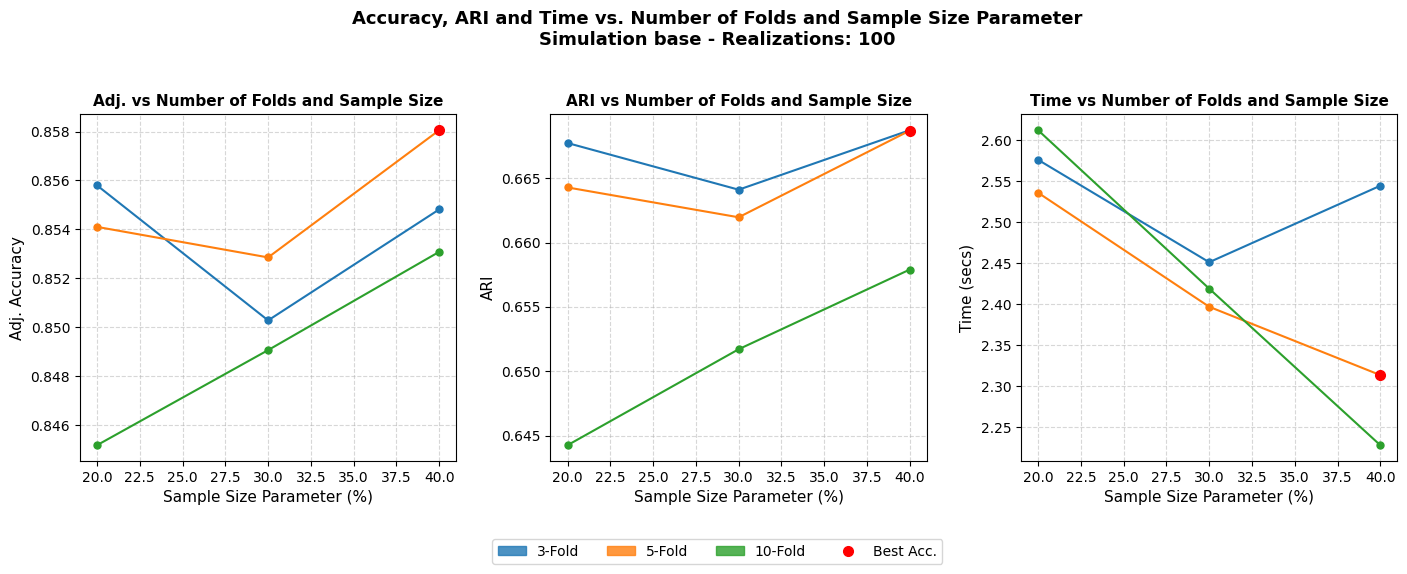

--------------------------------------------------
experiment_3b
--------------------------------------------------


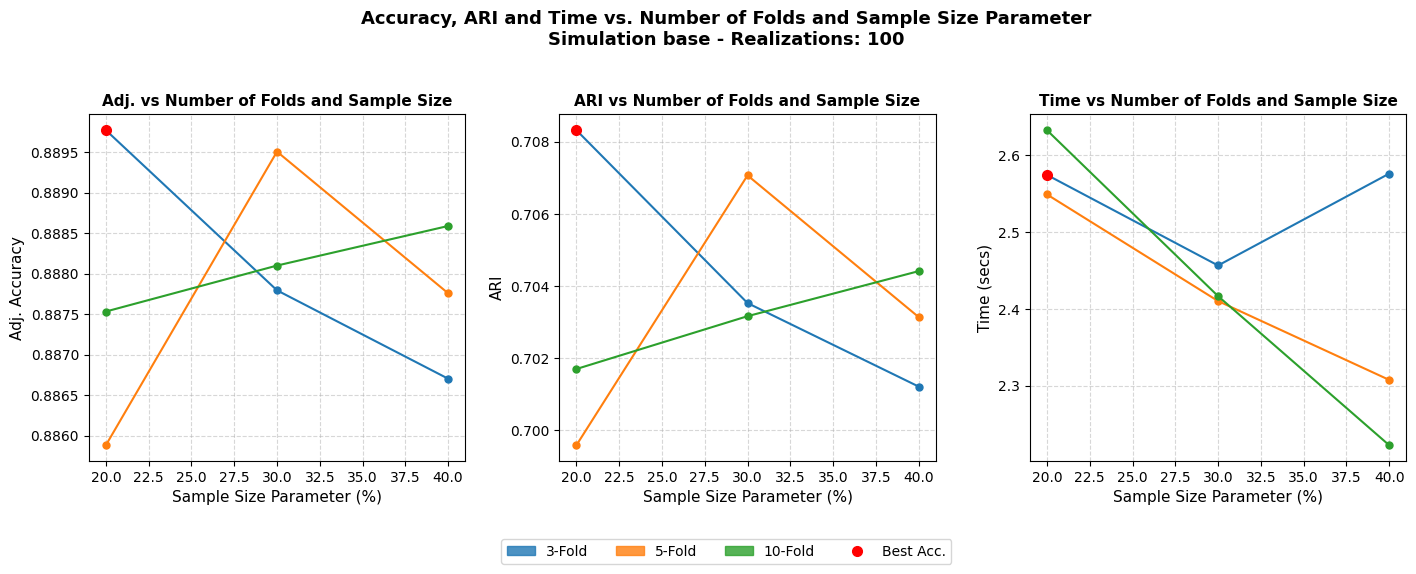

--------------------------------------------------
SIMULATION_SIZE_1
--------------------------------------------------
--------------------------------------------------
experiment_3a
--------------------------------------------------
'3a'
--------------------------------------------------
experiment_3b
--------------------------------------------------
'3b'
--------------------------------------------------
SIMULATION_DIM_1
--------------------------------------------------
--------------------------------------------------
experiment_3a
--------------------------------------------------
'3a'
--------------------------------------------------
experiment_3b
--------------------------------------------------
'3b'
--------------------------------------------------
SIMULATION_NUM_CLUSTERS_1
--------------------------------------------------
--------------------------------------------------
experiment_3a
--------------------------------------------------
'3a'
----------------------------

In [7]:
for data_id in DATA_IDS:

    print('-'*50)
    print(data_id.upper())
    print('-'*50)

    for mode in MODES:

        print('-'*50)
        print(f'experiment_{mode}')
        print('-'*50)

        try:

            error_style = None
            results_dir = os.path.join(project_path, 'results', f'experiment_{mode}', data_id)
            plot_filename = f'plot_results_exp_{mode}_{data_id}.png'
            save_path = os.path.join(results_dir, plot_filename)

            plot_experiment_3_results(
                df=df_results[data_id][mode], 
                df_avg=df_avg_results[data_id][mode],
                data_name=data_id, 
                num_realizations=N_REALIZATIONS,
                error_style=error_style,
                #ylim_acc=ylim_acc,
                #ylim_ari=ylim_ari,
                #ylim_time=ylim_time,
                #save_path=save_path
            )    

        except Exception as e:
            print(e)

--------------------------------------------------
SIMULATION_BASE
--------------------------------------------------
--------------------------------------------------
experiment_3a
--------------------------------------------------


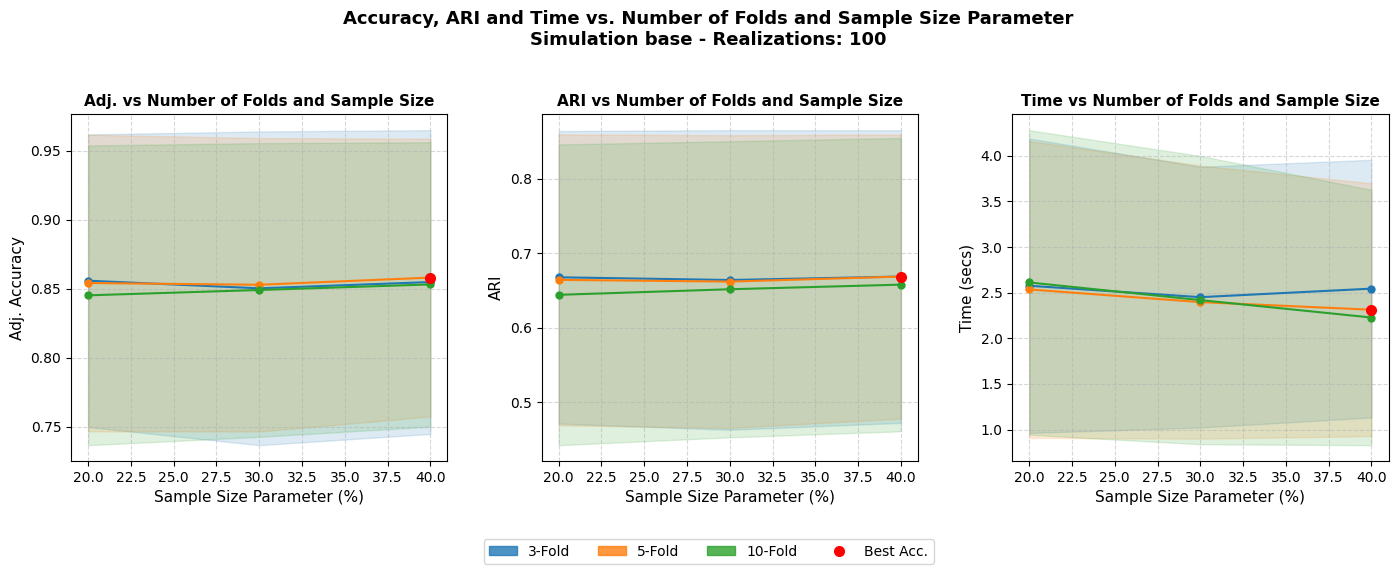

--------------------------------------------------
experiment_3b
--------------------------------------------------


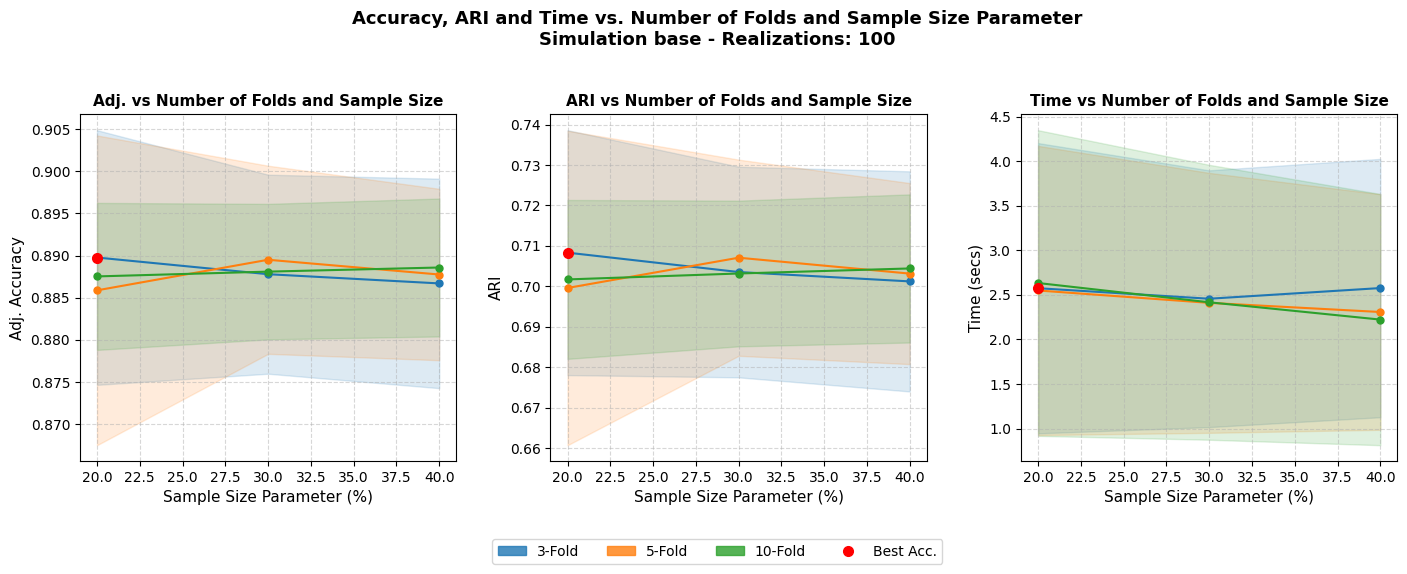

--------------------------------------------------
SIMULATION_SIZE_1
--------------------------------------------------
--------------------------------------------------
experiment_3a
--------------------------------------------------
'3a'
--------------------------------------------------
experiment_3b
--------------------------------------------------
'3b'
--------------------------------------------------
SIMULATION_DIM_1
--------------------------------------------------
--------------------------------------------------
experiment_3a
--------------------------------------------------
'3a'
--------------------------------------------------
experiment_3b
--------------------------------------------------
'3b'
--------------------------------------------------
SIMULATION_NUM_CLUSTERS_1
--------------------------------------------------
--------------------------------------------------
experiment_3a
--------------------------------------------------
'3a'
----------------------------

In [9]:
for data_id in DATA_IDS:

    print('-'*50)
    print(data_id.upper())
    print('-'*50)

    for mode in MODES:

        print('-'*50)
        print(f'experiment_{mode}')
        print('-'*50)

        try:

            error_style = 'fill'
            results_dir = os.path.join(project_path, 'results', f'experiment_{mode}', data_id)
            plot_filename = f'plot_results_exp_{mode}_{data_id}.png'
            save_path = os.path.join(results_dir, plot_filename)

            plot_experiment_3_results(
                df=df_results[data_id][mode], 
                df_avg=df_avg_results[data_id][mode],
                data_name=data_id, 
                num_realizations=N_REALIZATIONS,
                error_style=error_style,
                #ylim_acc=ylim_acc,
                #ylim_ari=ylim_ari,
                #ylim_time=ylim_time,
                #save_path=save_path
            )    

        except Exception as e:
            print(e)

--------------------------------------------------
SIMULATION_BASE
--------------------------------------------------
--------------------------------------------------
experiment_3a
--------------------------------------------------


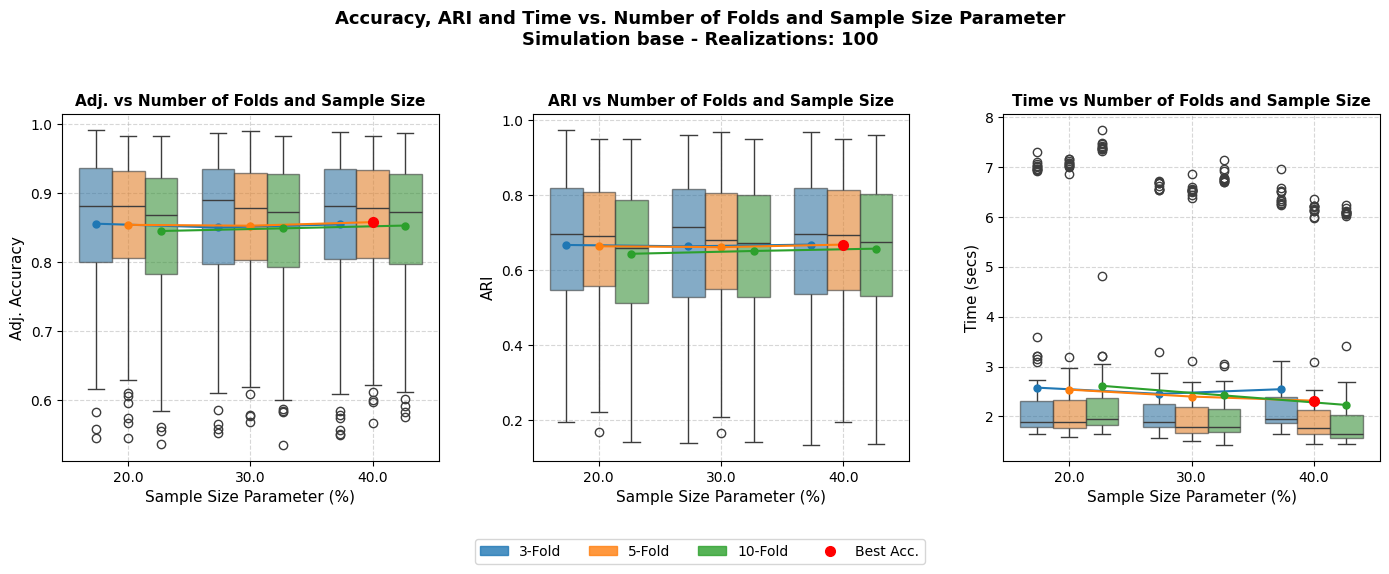

--------------------------------------------------
experiment_3b
--------------------------------------------------


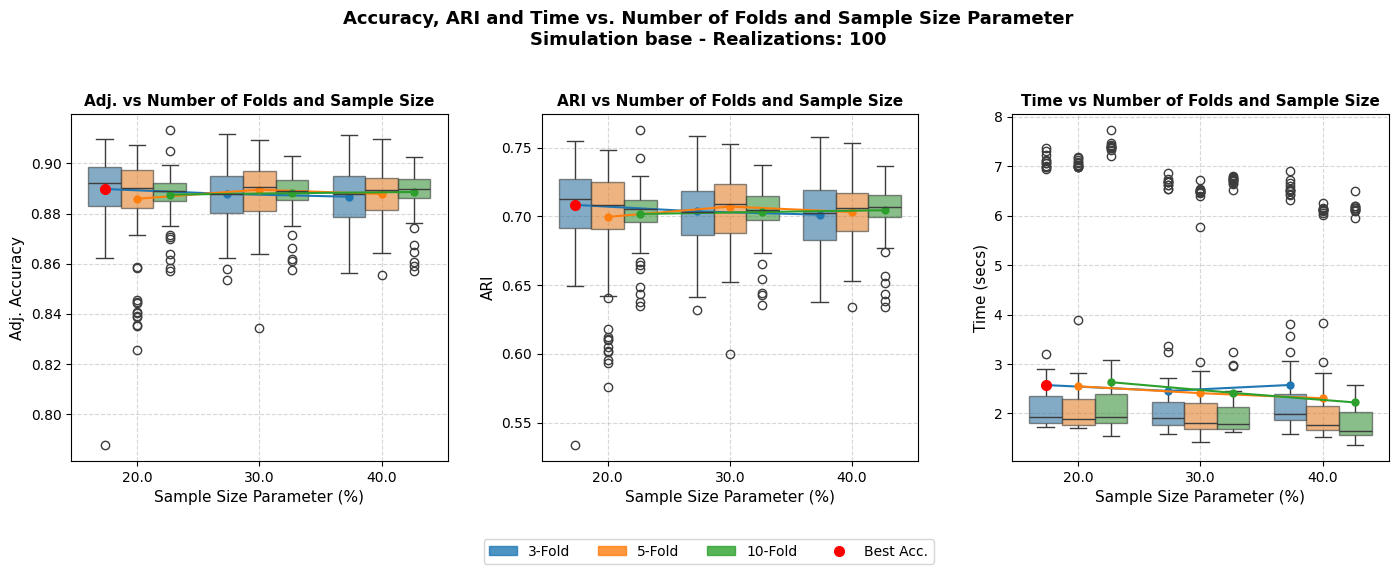

--------------------------------------------------
SIMULATION_SIZE_1
--------------------------------------------------
--------------------------------------------------
experiment_3a
--------------------------------------------------
'3a'
--------------------------------------------------
experiment_3b
--------------------------------------------------
'3b'
--------------------------------------------------
SIMULATION_DIM_1
--------------------------------------------------
--------------------------------------------------
experiment_3a
--------------------------------------------------
'3a'
--------------------------------------------------
experiment_3b
--------------------------------------------------
'3b'
--------------------------------------------------
SIMULATION_NUM_CLUSTERS_1
--------------------------------------------------
--------------------------------------------------
experiment_3a
--------------------------------------------------
'3a'
----------------------------

In [10]:
for data_id in DATA_IDS:

    print('-'*50)
    print(data_id.upper())
    print('-'*50)

    for mode in MODES:

        print('-'*50)
        print(f'experiment_{mode}')
        print('-'*50)

        try:

            error_style = 'boxplot'
            results_dir = os.path.join(project_path, 'results', f'experiment_{mode}', data_id)
            plot_filename = f'plot_results_exp_{mode}_{data_id}.png'
            save_path = os.path.join(results_dir, plot_filename)

            plot_experiment_3_results(
                df=df_results[data_id][mode], 
                df_avg=df_avg_results[data_id][mode],
                data_name=data_id, 
                num_realizations=N_REALIZATIONS,
                error_style=error_style,
                #ylim_acc=ylim_acc,
                #ylim_ari=ylim_ari,
                #ylim_time=ylim_time,
                #save_path=save_path
            )    

        except Exception as e:
            print(e)